# Shopper Spectrum: Customer Segmentation & Product Recommendations

**Domain:** E-Commerce and Retail Analytics  
**Techniques:** RFM Analysis · KMeans Clustering · Item-Based Collaborative Filtering  
**Dataset:** Online_Retail

**DONE BY:** B.Bhargav
---

## 📦 Step 1 — Imports & Dataset Loading

In [4]:
from google.colab import files

In [5]:
uploaded = files.upload()

Saving online_retail.csv to online_retail.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = pd.read_csv('online_retail.csv', encoding='latin-1')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
# Dataset info
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print('\nBasic Statistics:')
df.describe()

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Basic Statistics:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## 🔧 Step 2 — Data Preprocessing

In [8]:
# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])
print(f'After removing null CustomerID: {df.shape}')

# Exclude cancelled invoices (InvoiceNo starting with 'C')
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {df.shape}')

# Remove negative/zero quantity and price
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print(f'After removing invalid rows: {df.shape}')

# Clean CustomerID
df['CustomerID'] = df['CustomerID'].astype(int)

# Feature: TotalPrice
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('\nCleaned dataset sample:')
df.head()

After removing null CustomerID: (406829, 8)
After removing cancellations: (397924, 8)
After removing invalid rows: (397884, 8)

Cleaned dataset sample:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 📊 Step 3 — Exploratory Data Analysis (EDA)

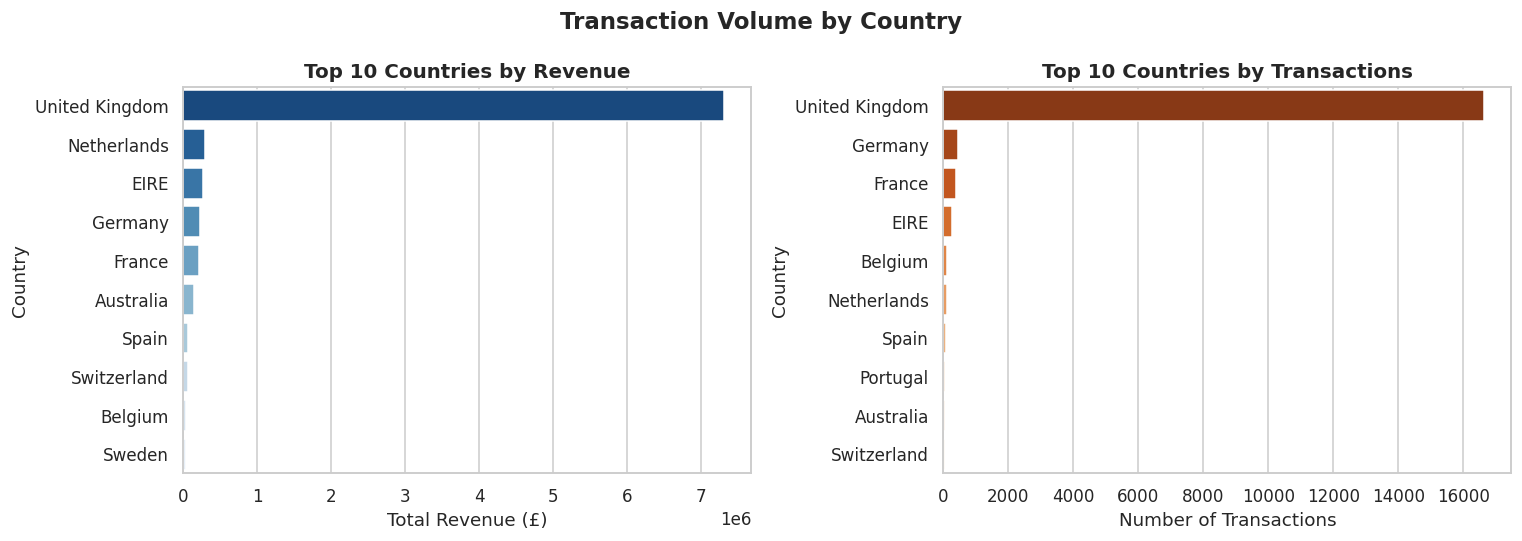

In [9]:
# 3.1 Transaction volume by country
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_countries_rev = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_rev.values, y=top_countries_rev.index, palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Countries by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (£)')

top_countries_txn = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries_txn.values, y=top_countries_txn.index, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Countries by Transactions', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Transactions')

plt.suptitle('Transaction Volume by Country', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

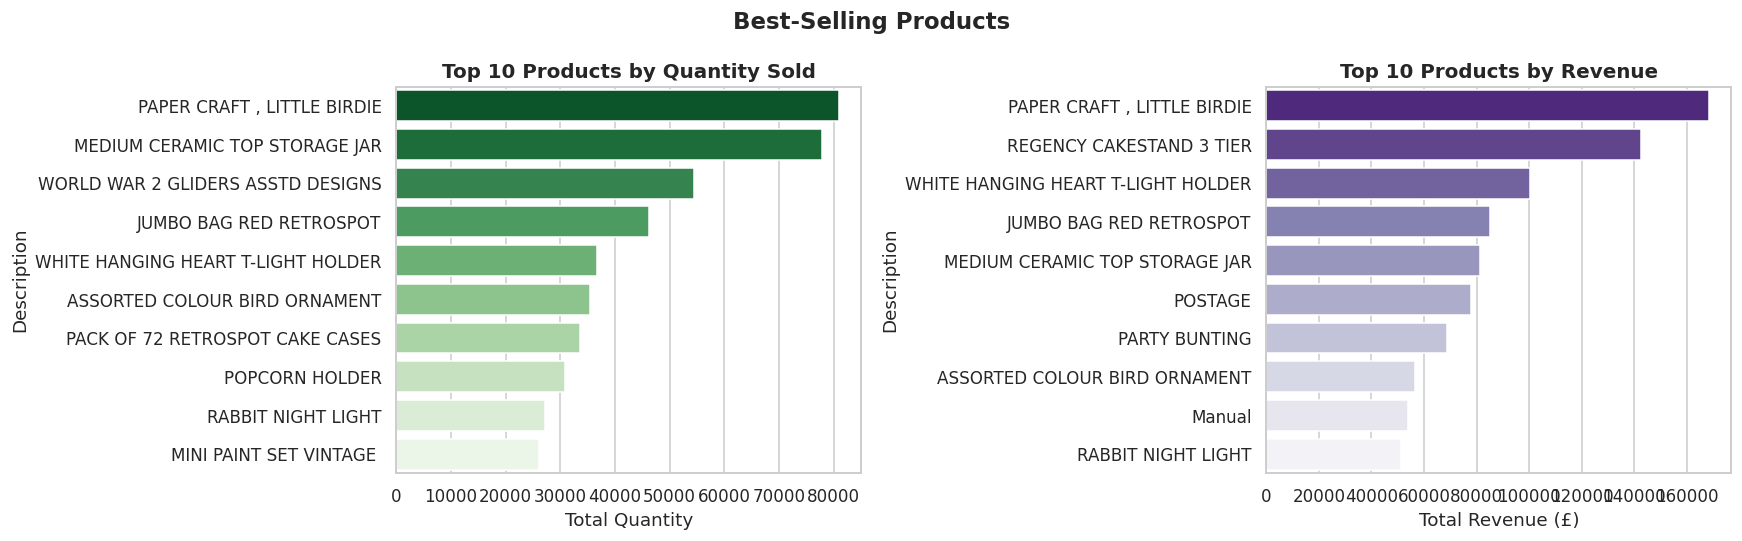

In [10]:
# 3.2 Top-selling products
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_products_qty = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products_qty.values, y=top_products_qty.index, palette='Greens_r', ax=axes[0])
axes[0].set_title('Top 10 Products by Quantity Sold', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Quantity')

top_products_rev = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products_rev.values, y=top_products_rev.index, palette='Purples_r', ax=axes[1])
axes[1].set_title('Top 10 Products by Revenue', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Revenue (£)')

plt.suptitle('Best-Selling Products', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

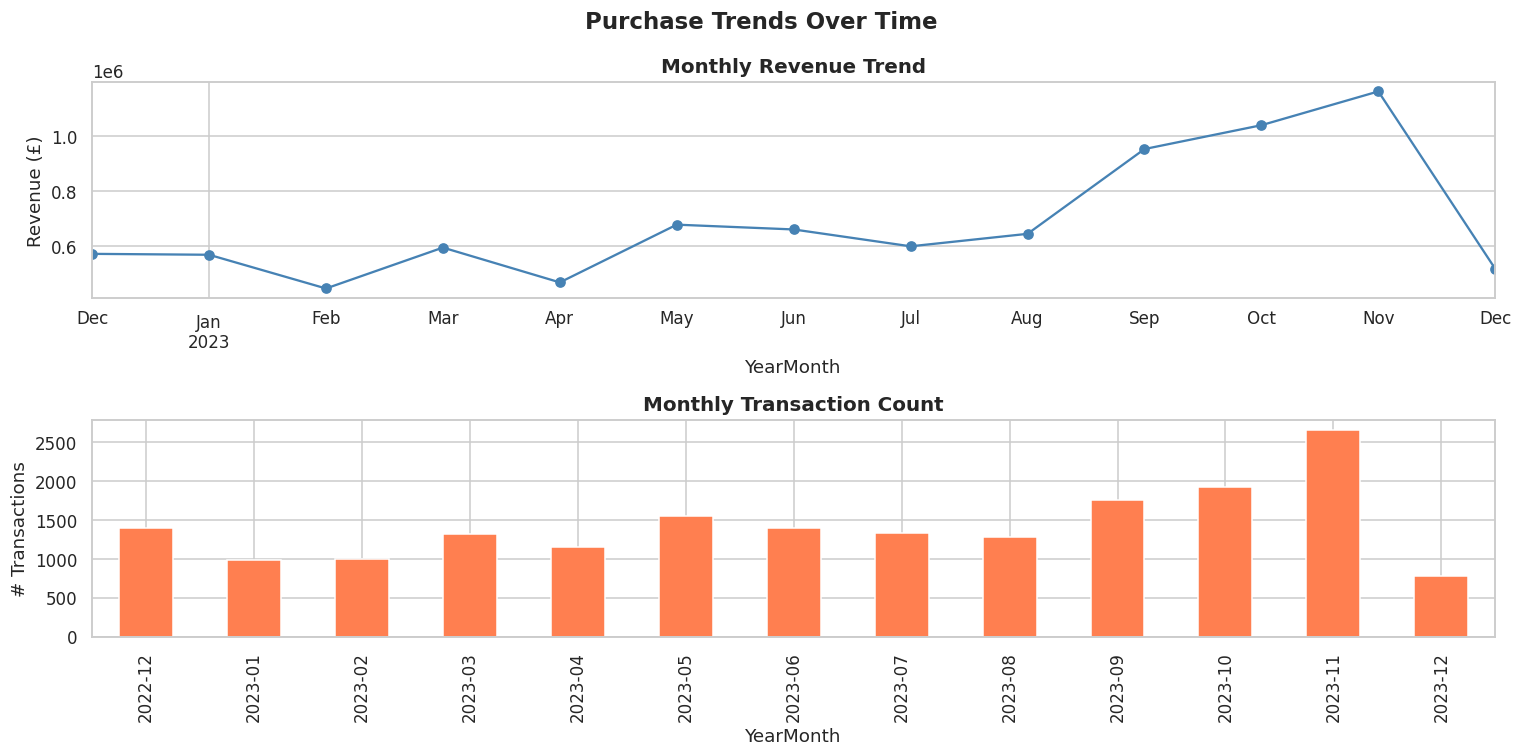

In [14]:
# 3.3 Purchase trends over time
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
monthly_rev = df.groupby('YearMonth')['TotalPrice'].sum()
monthly_txn = df.groupby('YearMonth')['InvoiceNo'].nunique()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
monthly_rev.plot(kind='line', marker='o', color='steelblue', ax=axes[0])
axes[0].set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
monthly_txn.plot(kind='bar', color='coral', ax=axes[1])
axes[1].set_title('Monthly Transaction Count', fontsize=13, fontweight='bold')
axes[1].set_ylabel('# Transactions')
plt.suptitle('Purchase Trends Over Time', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

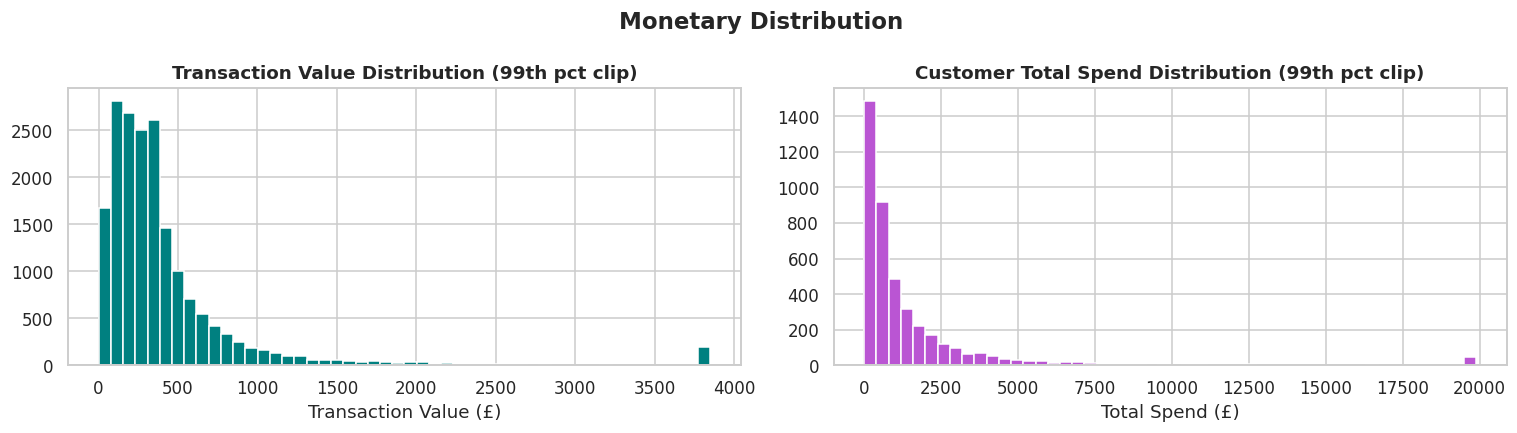

In [15]:
# 3.4 Monetary distribution per transaction
transaction_value = df.groupby('InvoiceNo')['TotalPrice'].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(transaction_value.clip(upper=transaction_value.quantile(0.99)), bins=50,
             color='teal', edgecolor='white')
axes[0].set_title('Transaction Value Distribution (99th pct clip)', fontweight='bold')
axes[0].set_xlabel('Transaction Value (£)')

customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()
axes[1].hist(customer_spend.clip(upper=customer_spend.quantile(0.99)), bins=50,
             color='mediumorchid', edgecolor='white')
axes[1].set_title('Customer Total Spend Distribution (99th pct clip)', fontweight='bold')
axes[1].set_xlabel('Total Spend (£)')

plt.suptitle('Monetary Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔢 Step 4 — RFM Feature Engineering

In [13]:
# Snapshot date = 1 day after latest transaction
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalPrice',  'sum')
).reset_index()

print(f'RFM table shape: {rfm.shape}')
rfm.head(10)

Snapshot date: 2023-12-10 12:50:00
RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40
5,12352,36,8,2506.04
6,12353,204,1,89.00
7,12354,232,1,1079.40
8,12355,214,1,459.40
9,12356,23,3,2811.43


In [16]:
print('RFM Statistics:')
rfm[['Recency','Frequency','Monetary']].describe()

RFM Statistics:


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


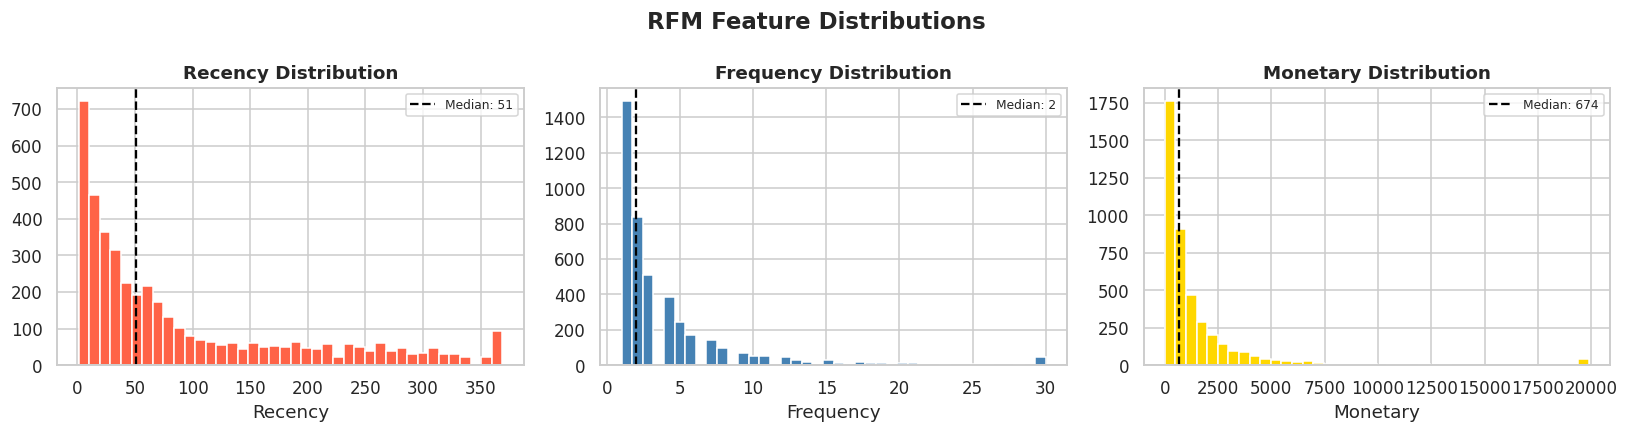

In [17]:
# RFM Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('Recency','tomato'), ('Frequency','steelblue'), ('Monetary','gold')]

for ax, (col, color) in zip(axes, pairs):
    vals = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(vals, bins=40, color=color, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontweight='bold')
    ax.set_xlabel(col)
    ax.axvline(rfm[col].median(), color='black', linestyle='--', label=f'Median: {rfm[col].median():.0f}')
    ax.legend(fontsize=8)

plt.suptitle('RFM Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🤖 Step 5 — KMeans Clustering

In [18]:
# Standardize RFM
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
print('Scaled RFM (first 5 rows):')
print(rfm_scaled[:5])

Scaled RFM (first 5 rows):
[[ 2.33457414 -0.4250965   8.35866818]
 [-0.90534032  0.3544168   0.25096626]
 [-0.17535959 -0.03533985 -0.02859601]
 [-0.73534481 -0.4250965  -0.0330118 ]
 [ 2.17457836 -0.4250965  -0.19134727]]


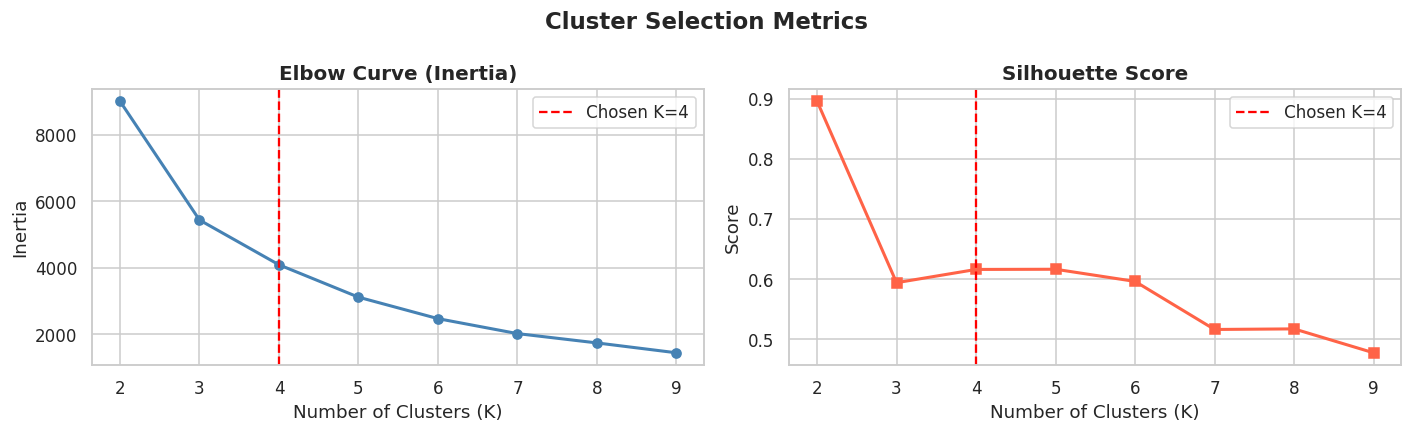

K=2  Silhouette=0.8958
K=3  Silhouette=0.5942
K=4  Silhouette=0.6162
K=5  Silhouette=0.6165
K=6  Silhouette=0.5963
K=7  Silhouette=0.5165
K=8  Silhouette=0.5175
K=9  Silhouette=0.4777


In [19]:
# Elbow Method + Silhouette Score
inertias, sil_scores = [], []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_range, inertias, marker='o', color='steelblue', linewidth=2)
ax1.set_title('Elbow Curve (Inertia)', fontweight='bold', fontsize=13)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.axvline(4, color='red', linestyle='--', label='Chosen K=4')
ax1.legend()

ax2.plot(K_range, sil_scores, marker='s', color='tomato', linewidth=2)
ax2.set_title('Silhouette Score', fontweight='bold', fontsize=13)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Score')
ax2.axvline(4, color='red', linestyle='--', label='Chosen K=4')
ax2.legend()

plt.suptitle('Cluster Selection Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f'K={k}  Silhouette={s:.4f}')

In [20]:
# Final KMeans with K=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)
print(f'Final inertia: {km_final.inertia_:.2f}')
print(f'Silhouette score: {silhouette_score(rfm_scaled, rfm["Cluster"]):.4f}')

Final inertia: 4092.14
Silhouette score: 0.6162


In [21]:
# Cluster Profiling
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print('Cluster Mean RFM Values:')
print(cluster_summary.round(2))

# Assign semantic labels
scores = {c: -row['Recency'] + row['Frequency']*50 + row['Monetary']/100
          for c, row in cluster_summary.iterrows()}
sorted_clusters = sorted(scores, key=scores.get, reverse=True)
label_names = ['High-Value', 'Regular', 'Occasional', 'At-Risk']
rank_map = {sorted_clusters[i]: label_names[i] for i in range(4)}

rfm['Segment'] = rfm['Cluster'].map(rank_map)
print('\nCluster to Segment mapping:', rank_map)
print('\nSegment Distribution:')
print(rfm['Segment'].value_counts())

Cluster Mean RFM Values:
         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09

Cluster to Segment mapping: {2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}

Segment Distribution:
Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


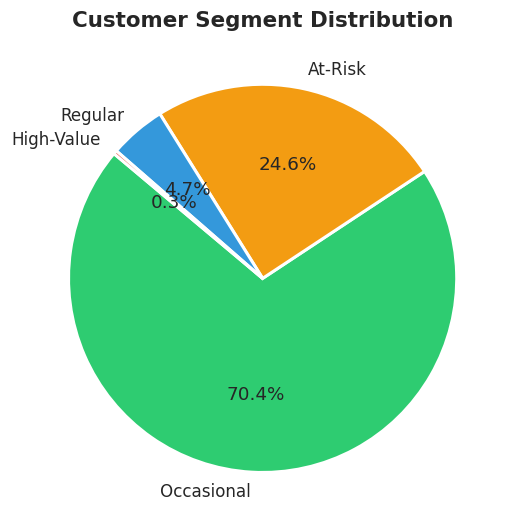

In [22]:
# Segment Pie Chart
colors = {'High-Value':'#e74c3c','Regular':'#3498db','Occasional':'#2ecc71','At-Risk':'#f39c12'}
seg_counts = rfm['Segment'].value_counts()
fig, ax = plt.subplots(figsize=(7, 5))
ax.pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
       colors=[colors[s] for s in seg_counts.index], startangle=140,
       wedgeprops={'edgecolor':'white', 'linewidth':2})
ax.set_title('Customer Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

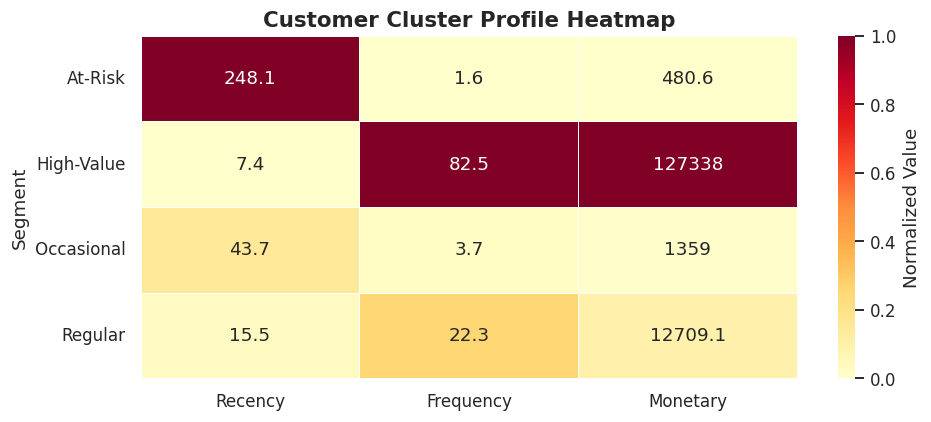


Actual mean RFM per Segment:
            Recency  Frequency   Monetary
Segment                                  
At-Risk      248.08       1.55     480.62
High-Value     7.38      82.54  127338.31
Occasional    43.70       3.68    1359.05
Regular       15.50      22.33   12709.09


In [23]:
# Cluster Profile Heatmap
profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min())

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(profile_norm, annot=profile.round(1), fmt='g', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Value'})
ax.set_title('Customer Cluster Profile Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nActual mean RFM per Segment:')
print(profile.round(2))

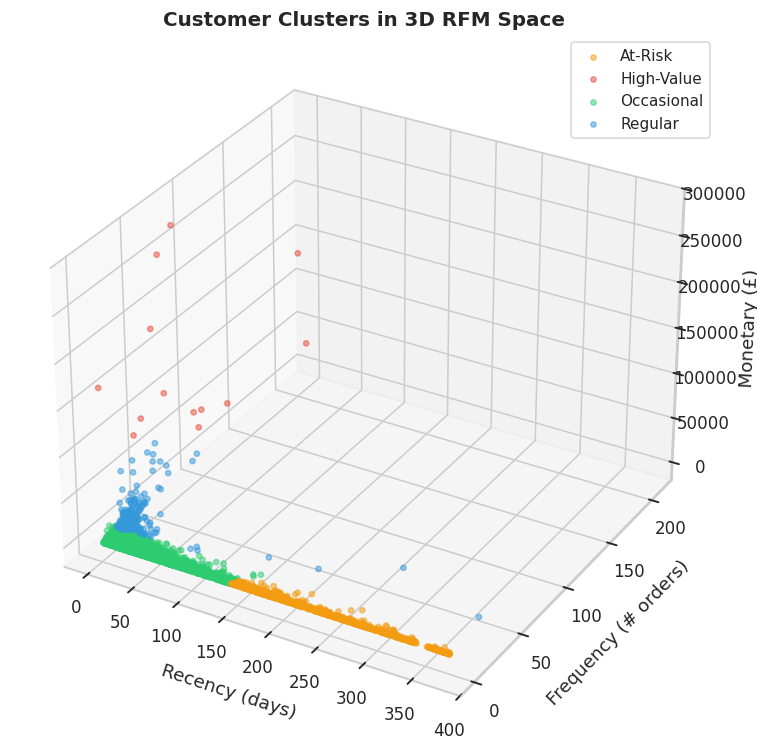

In [24]:
# 3D Scatter Plot of Clusters
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection='3d')
for seg, grp in rfm.groupby('Segment'):
    ax.scatter(grp['Recency'], grp['Frequency'], grp['Monetary'],
               label=seg, alpha=0.5, s=12, c=colors.get(seg, 'gray'))
ax.set_xlabel('Recency (days)', labelpad=8)
ax.set_ylabel('Frequency (# orders)', labelpad=8)
ax.set_zlabel('Monetary (£)', labelpad=8)
ax.set_title('Customer Clusters in 3D RFM Space', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

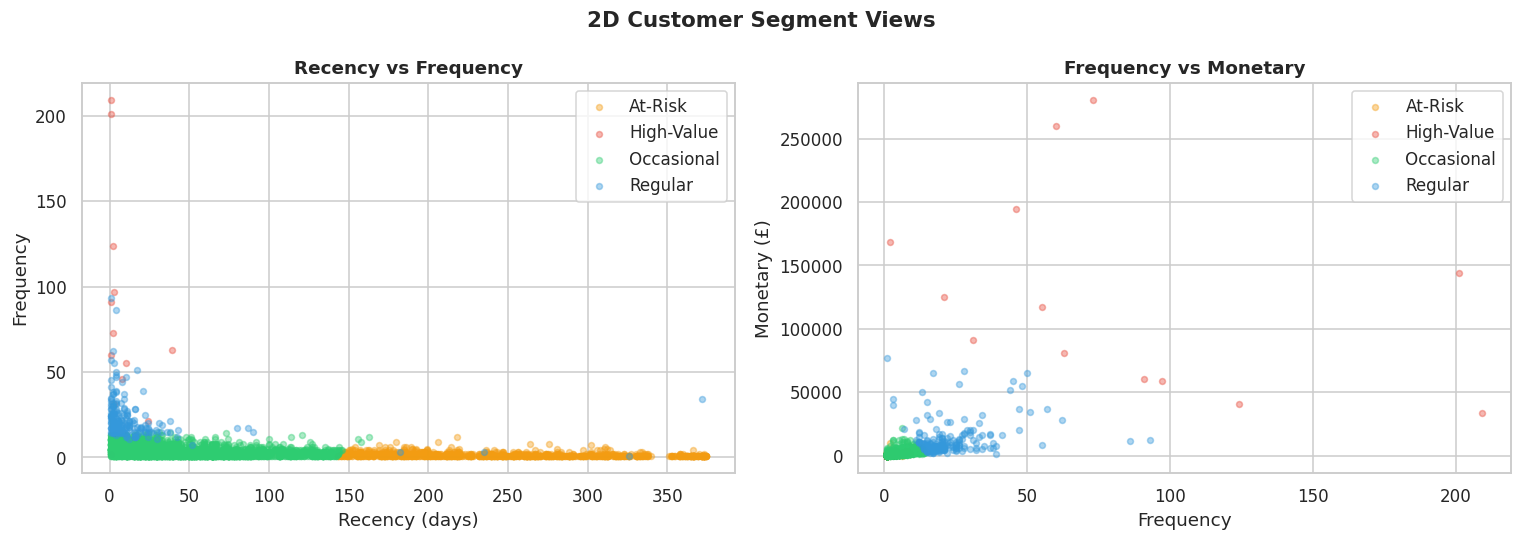

In [25]:
# 2D scatter: Recency vs Monetary (colored by segment)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for seg, grp in rfm.groupby('Segment'):
    axes[0].scatter(grp['Recency'], grp['Frequency'], label=seg,
                    alpha=0.4, s=15, c=colors.get(seg))
    axes[1].scatter(grp['Frequency'], grp['Monetary'], label=seg,
                    alpha=0.4, s=15, c=colors.get(seg))
axes[0].set_xlabel('Recency (days)'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Recency vs Frequency', fontweight='bold'); axes[0].legend()
axes[1].set_xlabel('Frequency'); axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary', fontweight='bold'); axes[1].legend()
plt.suptitle('2D Customer Segment Views', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 Step 6 — Product Recommendation (Item-Based Collaborative Filtering)

In [26]:
# Build Customer–Product matrix (UK only for focus)
uk_df = df[df['Country'] == 'United Kingdom'].copy()
prod_matrix = uk_df.groupby(['CustomerID','Description'])['Quantity'].sum().unstack(fill_value=0)
print(f'Product matrix shape: {prod_matrix.shape}')
print(f'Customers: {prod_matrix.shape[0]}, Products: {prod_matrix.shape[1]}')
prod_matrix.iloc[:4, :5]

Product matrix shape: (3920, 3844)
Customers: 3920, Products: 3844


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY
CustomerID,,,,,
12346,0,0,0,0,0
12747,0,0,0,0,0
12748,0,8,0,2,0
12749,0,0,0,0,0


In [27]:
# Compute cosine similarity between products
item_sim = cosine_similarity(prod_matrix.T)
item_sim_df = pd.DataFrame(item_sim, index=prod_matrix.columns, columns=prod_matrix.columns)
print(f'Similarity matrix shape: {item_sim_df.shape}')
item_sim_df.iloc[:4, :4]

Similarity matrix shape: (3844, 3844)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK
Description,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000244,0.000805
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.012651,0.014168
DOLLY GIRL BEAKER,0.000244,0.012651,1.000000,0.103817
I LOVE LONDON MINI BACKPACK,0.000805,0.014168,0.103817,1.000000


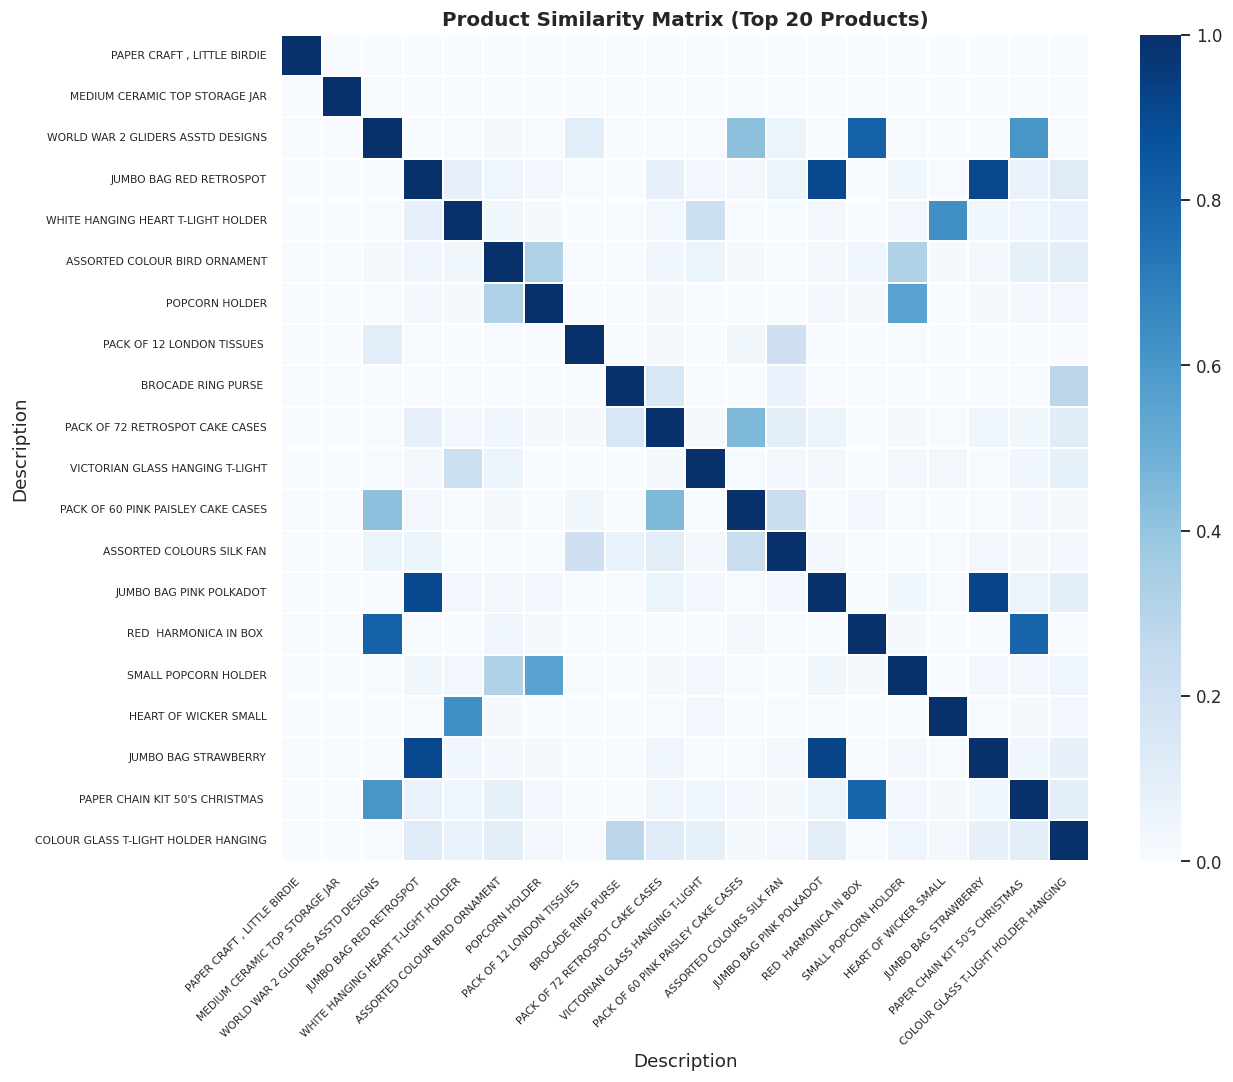

In [28]:
# Product Similarity Heatmap (Top 20 products)
top20 = uk_df.groupby('Description')['Quantity'].sum().nlargest(20).index
sim_top20 = item_sim_df.loc[top20, top20]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_top20, cmap='Blues', ax=ax, xticklabels=True, yticklabels=True,
            linewidths=0.3, linecolor='white')
ax.set_title('Product Similarity Matrix (Top 20 Products)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

In [29]:
# Recommendation function
def recommend_products(product_name, similarity_df, top_n=5):
    """Return top N similar products using cosine similarity."""
    product_name = product_name.upper().strip()
    # Fuzzy match if exact not found
    if product_name not in similarity_df.index:
        matches = [p for p in similarity_df.index if product_name in p]
        if not matches:
            return [f'Product "{product_name}" not found in catalogue.']
        product_name = matches[0]
        print(f'Matched to: {product_name}')
    sim_scores = similarity_df[product_name].drop(index=product_name)
    top_products = sim_scores.sort_values(ascending=False).head(top_n).index.tolist()
    return top_products

# Test
test_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
recs = recommend_products(test_product, item_sim_df)
print(f'Top 5 recommendations for "{test_product}":')
for i, r in enumerate(recs, 1):
    print(f'  {i}. {r}')

Top 5 recommendations for "WHITE HANGING HEART T-LIGHT HOLDER":
  1. GIN + TONIC DIET METAL SIGN
  2. RED HANGING HEART T-LIGHT HOLDER
  3. WASHROOM METAL SIGN
  4. LAUNDRY 15C METAL SIGN
  5. GREEN VINTAGE SPOT BEAKER


In [30]:
# Another test
test_product2 = 'REGENCY CAKESTAND 3 TIER'
recs2 = recommend_products(test_product2, item_sim_df)
print(f'Top 5 recommendations for "{test_product2}":')
for i, r in enumerate(recs2, 1):
    print(f'  {i}. {r}')

Top 5 recommendations for "REGENCY CAKESTAND 3 TIER":
  1. BLACK LOVE BIRD T-LIGHT HOLDER
  2. MIRROR LOVE BIRD T-LIGHT HOLDER
  3. MINI PLAYING CARDS FUN FAIR 
  4. BLUE POLKADOT WRAP
  5. SLEEPING CAT ERASERS


## 💾 Step 7 — Save Models for Streamlit App

In [31]:
import os
os.makedirs('models', exist_ok=True)

pickle.dump(km_final,    open('models/kmeans_model.pkl','wb'))
pickle.dump(scaler,      open('models/scaler.pkl','wb'))
pickle.dump(rank_map,    open('models/rank_map.pkl','wb'))
pickle.dump(item_sim_df, open('models/item_similarity.pkl','wb'))
rfm.to_csv('models/rfm_data.csv', index=False)

print('✅ Models saved:')
print('  - models/kmeans_model.pkl  → KMeans clustering model')
print('  - models/scaler.pkl        → StandardScaler')
print('  - models/rank_map.pkl      → Cluster → Segment label mapping')
print('  - models/item_similarity.pkl → Product cosine similarity matrix')
print('  - models/rfm_data.csv      → Full RFM table with segments')

✅ Models saved:
  - models/kmeans_model.pkl  → KMeans clustering model
  - models/scaler.pkl        → StandardScaler
  - models/rank_map.pkl      → Cluster → Segment label mapping
  - models/item_similarity.pkl → Product cosine similarity matrix
  - models/rfm_data.csv      → Full RFM table with segments


##  Summary



### Customer Segments Interpretation
- **High-Value**  — Very recent, very frequent, highest spend. Reward and retain.
- **Regular**  — Steady purchasers with moderate RFM. Upsell opportunities.
- **Occasional**  — Infrequent buyers with moderate recency. Re-engagement campaigns.
- **At-Risk**  — Long time since purchase, low frequency and monetary. Win-back programs.